<a href="https://colab.research.google.com/github/Zacheriac/Reconocimiento-Frutas/blob/main/RECONOCIMIENTO_DE_FRUTAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**Se utilizó un dataset de Kaggle con 36 tipos de frutas y verduras. Lo elegí porque ya estaba separado en entrenamiento y prueba, lo que evita errores al evaluar el modelo. Además, tiene variaciones reales de iluminación y fondo, lo que obliga al modelo a aprender patrones generales y no solo memorizar imágenes.**

In [ ]:
import kagglehub, os, io
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import ipywidgets as widgets
from IPython.display import display, clear_output

#dataset porque ya viene dividido en entrenamiento y prueba
path = kagglehub.dataset_download("kritikseth/fruit-and-vegetable-image-recognition")
ruta_train = f"{path}/train"
ruta_test  = f"{path}/test"
print("Clases:", sorted(os.listdir(ruta_train)))

Using Colab cache for faster access to the 'fruit-and-vegetable-image-recognition' dataset.
Clases: ['apple', 'banana', 'beetroot', 'bell pepper', 'cabbage', 'capsicum', 'carrot', 'cauliflower', 'chilli pepper', 'corn', 'cucumber', 'eggplant', 'garlic', 'ginger', 'grapes', 'jalepeno', 'kiwi', 'lemon', 'lettuce', 'mango', 'onion', 'orange', 'paprika', 'pear', 'peas', 'pineapple', 'pomegranate', 'potato', 'raddish', 'soy beans', 'spinach', 'sweetcorn', 'sweetpotato', 'tomato', 'turnip', 'watermelon']


**El dataset solo contiene el nombre de la fruta o verdura (clasificación T2), pero el proyecto requería una clasificación adicional por sabor (T1).**

In [ ]:
etiquetas_padre = {
    'apple':'dulce', 'banana':'dulce', 'grapes':'dulce', 'mango':'dulce',
    'pear':'dulce', 'watermelon':'dulce', 'strawberry':'dulce',
    'orange':'acida', 'kiwi':'acida', 'lemon':'acida',
    'pineapple':'acida', 'pomegranate':'acida', 'tomato':'acida',
    'avocado':'neutra', 'coconut':'neutra', 'corn':'neutra',
    'cucumber':'neutra', 'carrot':'neutra', 'papaya':'neutra',
    'beetroot':'neutra', 'cabbage':'neutra', 'capsicum':'neutra',
    'chilli pepper':'neutra', 'garlic':'neutra', 'ginger':'neutra',
    'onion':'neutra', 'potato':'neutra', 'spinach':'neutra',
    'sweetcorn':'neutra', 'sweet potato':'neutra', 'turnip':'neutra',
}

clases = sorted(os.listdir(ruta_train))
print(f"Total clases (T2): {len(clases)}")
for c in clases:
    print(f"  {c:20s} → {etiquetas_padre.get(c.lower(), 'otra')}")

Total clases (T2): 36
  apple                → dulce
  banana               → dulce
  beetroot             → neutra
  bell pepper          → otra
  cabbage              → neutra
  capsicum             → neutra
  carrot               → neutra
  cauliflower          → otra
  chilli pepper        → neutra
  corn                 → neutra
  cucumber             → neutra
  eggplant             → otra
  garlic               → neutra
  ginger               → neutra
  grapes               → dulce
  jalepeno             → otra
  kiwi                 → acida
  lemon                → acida
  lettuce              → otra
  mango                → dulce
  onion                → neutra
  orange               → acida
  paprika              → otra
  pear                 → dulce
  peas                 → otra
  pineapple            → acida
  pomegranate          → acida
  potato               → neutra
  raddish              → otra
  soy beans            → otra
  spinach              → neutra
  sweetcorn   

In [ ]:
#redimensionamos las imagenes
IMG_SIZE  = (100, 100)
BATCH     = 32

# Data augmentation para que reconozca fotos reales
datagen_train = ImageDataGenerator(
    #Normalización
    rescale=1./255,
    rotation_range=20,        # rota la imagen hasta 20°
    zoom_range=0.2,           # hace zoom aleatorio
    horizontal_flip=True,     # voltea horizontalmente
    brightness_range=[0.8, 1.2],  # varía el brillo
    validation_split=0.2
)

datagen_test = ImageDataGenerator(rescale=1./255)

#Entrenamiento (80%) subset='training'
#Validación (20%) subset='validation'
train_gen = datagen_train.flow_from_directory(
    ruta_train,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode='sparse',
    subset='training',
    shuffle=True
)

val_gen = datagen_train.flow_from_directory(
    ruta_train,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode='sparse',
    subset='validation',
    shuffle=False
)

# Guardar mapeo de clases
idx_a_clase = {v: k for k, v in train_gen.class_indices.items()}
print(f"\nClases detectadas: {len(idx_a_clase)}")
print("Índice → clase:", idx_a_clase)

Found 2510 images belonging to 36 classes.
Found 605 images belonging to 36 classes.

Clases detectadas: 36
Índice → clase: {0: 'apple', 1: 'banana', 2: 'beetroot', 3: 'bell pepper', 4: 'cabbage', 5: 'capsicum', 6: 'carrot', 7: 'cauliflower', 8: 'chilli pepper', 9: 'corn', 10: 'cucumber', 11: 'eggplant', 12: 'garlic', 13: 'ginger', 14: 'grapes', 15: 'jalepeno', 16: 'kiwi', 17: 'lemon', 18: 'lettuce', 19: 'mango', 20: 'onion', 21: 'orange', 22: 'paprika', 23: 'pear', 24: 'peas', 25: 'pineapple', 26: 'pomegranate', 27: 'potato', 28: 'raddish', 29: 'soy beans', 30: 'spinach', 31: 'sweetcorn', 32: 'sweetpotato', 33: 'tomato', 34: 'turnip', 35: 'watermelon'}


**Se utilizó una CNN con MobileNetV2. Esta red ya está entrenada y sabe detectar patrones como bordes, colores y texturas. En lugar de entrenarla desde cero, reutilicé ese conocimiento (transfer learning) y solo entrené las capas finales para clasificar las 36 clases.**

In [ ]:
# Usamos MobileNetV2 que ya sabe reconocer formas, colores y texturas(preentreno)
#Uso de CNN : es la arquitectura más adecuada para imágenes.
#Transfer Learning: Ya fue entrenado con millones de imágenes (ImageNet) Ya sabe detectar bordes, texturas y formas
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(100, 100, 3),
    include_top=False,       # quitamos su cabeza clasificadora
    weights='imagenet'       # pesos pre-entrenados con millones de imágenes
)

# Congelamos la base — no la reentrenamos, solo usamos lo que ya sabe
base_model.trainable = False

#GlobalAveragePooling → resume la información visual
#Capa densa (256 neuronas) → aprende combinaciones de características
#Dropout (40%) → evita sobreajuste
#Softmax → convierte la salida en probabilidades
modelo = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(num_clases, activation='softmax')
])

modelo.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

modelo.summary()

/tmp/ipykernel_14838/2454451165.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 36)             │         9,252 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,595,172 (9.90 MB)

 Trainable params: 337,188 (1.29 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

**ENTRENAMIENTO**

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


79/79 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.2900 - loss: 2.7128 - val_accuracy: 0.5983 - val_loss: 1.4252
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 129s 2s/step - accuracy: 0.5032 - loss: 1.6990 - val_accuracy: 0.6562 - val_loss: 1.1680
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.5809 - loss: 1.4037 - val_accuracy: 0.7240 - val_loss: 0.9691
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 128s 2s/step - accuracy: 0.6179 - loss: 1.3063 - val_accuracy: 0.7025 - val_loss: 0.9581
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.6669 - loss: 1.1101 - val_accuracy: 0.7240 - val_loss: 0.8805
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 129s 2s/step - accuracy: 0.6845 - loss: 1.0425 - val_accuracy: 0.7256 - val_loss: 0.8786
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - accuracy: 0.6861 - loss: 0.9920 - val_accuracy: 0.7273 - val_loss: 0.9134
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 131s 2s/step - accuracy: 0.7243 - loss: 0.8969 - val_accuracy: 0.7322 - val_loss: 0.

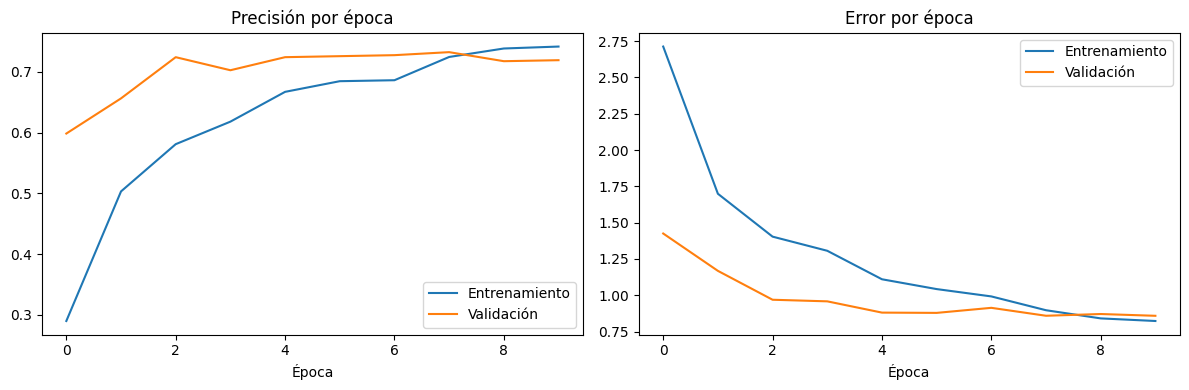

In [ ]:
#Adam → optimizador eficiente
#sparse_categorical_crossentropy → adecuado para múltiples clases
#EarlyStopping → detiene el entrenamiento si deja de mejorar,evita sobreentrenamiento y ahorra tiempo

historia = modelo.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            patience=3,
            restore_best_weights=True,
            monitor='val_accuracy'
        )
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(historia.history['accuracy'],     label='Entrenamiento')
axes[0].plot(historia.history['val_accuracy'], label='Validación')
axes[0].set_title('Precisión por época')
axes[0].set_xlabel('Época')
axes[0].legend()

axes[1].plot(historia.history['loss'],     label='Entrenamiento')
axes[1].plot(historia.history['val_loss'], label='Validación')
axes[1].set_title('Error por época')
axes[1].set_xlabel('Época')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
test_gen = datagen_test.flow_from_directory(
    ruta_test,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode='sparse',
    shuffle=False
)

#Evaluación del modelo
loss, acc = modelo.evaluate(test_gen)
total     = test_gen.samples
correctas = int(acc * total)
errores   = total - correctas

print("=" * 45)
print("  EVALUACIÓN FINAL DEL MODELO (CNN)")
print("=" * 45)
print(f"  Imágenes evaluadas  : {total}")
print(f"  Reconoció bien      : {correctas}")
print(f"  Falló en            : {errores}")
print(f"  Precisión (T2)      : {acc*100:.1f}%")
print(f"  Margen de error     : {(1-acc)*100:.1f}%")
print("=" * 45)

Found 359 images belonging to 36 classes.
12/12 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.8579 - loss: 0.4135
  EVALUACIÓN FINAL DEL MODELO (CNN)
  Imágenes evaluadas  : 359
  Reconoció bien      : 307
  Falló en            : 52
  Precisión (T2)      : 85.8%
  Margen de error     : 14.2%


In [ ]:
def predecir_imagen(contenido_bytes):
    img_original = Image.open(io.BytesIO(contenido_bytes)).convert('RGB')
    img_resized  = img_original.resize(IMG_SIZE)

    # Mostrar imagen
    plt.figure(figsize=(4, 4))
    plt.imshow(img_original)
    plt.axis('off')
    plt.title("Imagen subida")
    plt.show()

    # Preprocesar
    arr = np.array(img_resized) / 255.0
    arr = arr.reshape(1, 100, 100, 3)

    # Predecir imágenes nuevas
    predicciones  = modelo.predict(arr, verbose=0)[0]
    idx_top       = np.argsort(predicciones)[::-1][:3]  # top 3

    fruta_pred    = idx_a_clase[idx_top[0]]
    confianza     = predicciones[idx_top[0]] * 100
    sabor_pred    = etiquetas_padre.get(fruta_pred.lower(), 'otra')

    print("=" * 42)
    print(f"  T2 — Fruta   : {fruta_pred}")
    print(f"  Confianza    : {confianza:.1f}%")
    print(f"  Error posible: {100 - confianza:.1f}%")
    print("-" * 42)
    print(f"  T1 — Sabor   : {sabor_pred}")
    print("=" * 42)
    print("\n  Top 3 predicciones:")
    for i, idx in enumerate(idx_top):
        print(f"    {i+1}. {idx_a_clase[idx]:15s} {predicciones[idx]*100:.1f}%")

# Widget
uploader = widgets.FileUpload(accept='image/*', multiple=False, description='Subir imagen')
boton    = widgets.Button(description='Reconocer', button_style='success')
salida   = widgets.Output()

def al_clic(b):
    with salida:
        clear_output()
        if not uploader.value:
            print("Sube una imagen primero.")
            return
        val      = uploader.value
        contenido = list(val.values())[0]['content'] if isinstance(val, dict) else val[0]['content']
        predecir_imagen(bytes(contenido))

boton.on_click(al_clic)
display(widgets.HBox([uploader, boton]), salida)

Output()

**Se eligió el enfoque de CNN + transfer learning porque permite obtener buenos resultados con pocos datos.**